In [3]:
# ================================================
# 1. Imports
# ================================================
import pandas as pd
import numpy as np

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
import mlflow.xgboost

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna


import os
from pathlib import Path

print(os.getcwd())


# Create a process data directory if it doesn't already exist
processed_data_path = Path("/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/data/processed")
mlruns_path = Path("/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/mlruns")

/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/notebooks


In [4]:
#functions

def getColTypes(df):
    categorical_cols = df[mycols].select_dtypes(include=['object']).columns
    numeric_cols = df[mycols].select_dtypes(include=['number']).columns
    return categorical_cols,numeric_cols


def setCategoryColsToDf(df,categorical_cols):
    for col in categorical_cols:
        df[col] = df[col].astype('category')
    return df




# Helper function for evaluation
def evaluate_metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [5]:
train_df= pd.read_csv(processed_data_path/'featured_train.csv')
eval_df= pd.read_csv(processed_data_path/'featured_eval.csv')
hold_df= pd.read_csv(processed_data_path/'featured_hold.csv')

In [6]:
# # 1. Prepare data
mycols = ['flat_type_rank', 'region_ura_rank', 'town_rank','storey_range_rank','flat_model_rank'
         ,'distance_to_cbd', 'floor_area_sqm', 'remaining_lease_years','resale_price_index']
target = 'resale_price'

In [7]:
categorical_cols,numeric_cols = getColTypes(train_df)

train_df = setCategoryColsToDf(train_df,categorical_cols)
eval_df = setCategoryColsToDf(eval_df,categorical_cols)
hold_df = setCategoryColsToDf(hold_df,categorical_cols)


# Verify the changes
print(train_df[mycols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143129 entries, 0 to 143128
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   flat_type_rank         143129 non-null  int64  
 1   region_ura_rank        143129 non-null  int64  
 2   town_rank              143129 non-null  int64  
 3   storey_range_rank      143129 non-null  int64  
 4   flat_model_rank        143129 non-null  int64  
 5   distance_to_cbd        143129 non-null  float64
 6   floor_area_sqm         143129 non-null  float64
 7   remaining_lease_years  143129 non-null  int64  
 8   resale_price_index     143129 non-null  float64
dtypes: float64(3), int64(6)
memory usage: 9.8 MB
None


In [8]:
X_train = train_df[mycols]
y_train = train_df[target]

X_eval = eval_df[mycols]
y_eval = eval_df[target]

X_hold = hold_df[mycols]
y_hold = hold_df[target]

In [9]:
# ==============================================
# 3. Define Optuna objective function with MLflow
# ==============================================


def objective(trial):
    # 1. Define Random Forest hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.1, 1.0),
        "random_state": 42,
        "n_jobs": -1,
    }

    transformers = []
    # Check if the Index or list is not empty
    if len(categorical_cols) > 0:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        )

    preprocessor_rf = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough' 
    )

    # 2. Create the Pipeline using your existing preprocessor_rf
    # This automatically applies OneHotEncoding (if cols exist) or PassThrough
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_rf),
        ('regressor', RandomForestRegressor(**params))
    ])

    with mlflow.start_run(nested=True):
        # 3. Fit the entire pipeline (transforms + model)
        model_pipeline.fit(X_train, y_train)

        # 4. Predict and evaluate
        y_pred = model_pipeline.predict(X_eval)
        rmse, mae, r2 = evaluate_metrics(y_eval, y_pred)

        # Log hyperparameters + metrics
        mlflow.log_params(params)
        mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})

    return rmse


In [12]:
# ==============================================
# 4. Run Optuna study with MLflow
# ==============================================
# Force MLflow to always use the root project mlruns folder

# Set MLflow experiment (Optional, creates one if it doesn't exist)
mlflow.set_experiment("hdb_rf_optuna")
mlflow.set_tracking_uri('http://127.0.0.1:5000/')
#mlflow.set_tracking_uri(mlruns_path) # root path

#import subprocess
#subprocess.Popen(["mlflow", "ui", "--port", "5000"])

2026/04/11 14:33:18 INFO mlflow.tracking.fluent: Experiment with name 'hdb_rf_optuna' does not exist. Creating a new experiment.


In [15]:

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)

print("Best params:", study.best_trial.params)

[I 2026-04-11 14:36:14,627] A new study created in memory with name: no-name-2e1d2624-57f7-45fe-9e63-e5ada7e6d7a8
[I 2026-04-11 14:37:19,214] Trial 0 finished with value: 71328.32744999841 and parameters: {'n_estimators': 761, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 0.954764062168022}. Best is trial 0 with value: 71328.32744999841.


🏃 View run rare-flea-444 at: http://127.0.0.1:5000/#/experiments/343490741121494742/runs/8ad7b8539435447cb373ca2718e2c907
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343490741121494742


[I 2026-04-11 14:37:24,746] Trial 1 finished with value: 100658.5264408452 and parameters: {'n_estimators': 211, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 0.45432012782169207}. Best is trial 0 with value: 71328.32744999841.


🏃 View run dazzling-panda-958 at: http://127.0.0.1:5000/#/experiments/343490741121494742/runs/26bcad3cd92c4c529d33ef64ef42970c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343490741121494742


[I 2026-04-11 14:37:32,289] Trial 2 finished with value: 91825.7229584606 and parameters: {'n_estimators': 314, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 0.4252827903211758}. Best is trial 0 with value: 71328.32744999841.


...

🏃 View run blushing-carp-930 at: http://127.0.0.1:5000/#/experiments/343490741121494742/runs/36aad62d08f447ae901e729671bf4eaf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343490741121494742


[I 2026-04-11 14:43:56,205] Trial 13 finished with value: 67183.95044602684 and parameters: {'n_estimators': 613, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.8338706336332755}. Best is trial 13 with value: 67183.95044602684.


🏃 View run redolent-penguin-108 at: http://127.0.0.1:5000/#/experiments/343490741121494742/runs/d123695e534140da839aed540f860bda
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343490741121494742


[I 2026-04-11 14:44:45,895] Trial 14 finished with value: 69338.70907421963 and parameters: {'n_estimators': 579, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.824119985639965}. Best is trial 13 with value: 67183.95044602684.


🏃 View run inquisitive-wolf-227 at: http://127.0.0.1:5000/#/experiments/343490741121494742/runs/2b27bc64e6b24686a18f08f3ca836d57
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343490741121494742
Best params: {'n_estimators': 613, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.8338706336332755}


In [ ]:
# ==============================================
# 5. Train final model with best params and log to MLflow
# ==============================================


# ==============================================
# 5. Train final model with best params and log to MLflow
# ==============================================
best_params = study.best_trial.params

# Reconstruct the pipeline with the best params found by Optuna
transformers = []
# Check if the Index or list is not empty
if len(categorical_cols) > 0:
    transformers.append(
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    )

preprocessor_rf = ColumnTransformer(
    transformers=transformers,
    remainder='passthrough' 
)

best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('rf', RandomForestRegressor(**best_params, n_jobs=-1, random_state=42))
])

# Fit the entire pipeline
best_model_pipeline.fit(X_train, y_train)

# Predict using the pipeline (it will automatically preprocess X_eval)
y_pred = best_model_pipeline.predict(X_eval)

rmse, mae, r2 = evaluate_metrics(y_eval, y_pred)

print("Final tuned model performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Infer signature for the entire pipeline
signature = infer_signature(X_train, best_model_pipeline.predict(X_train))

# Log final model pipeline
with mlflow.start_run(run_name="best_random_forest_model"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    
    # Log the sklearn pipeline so it's ready for deployment
    mlflow.sklearn.log_model(
        sk_model=best_model_pipeline, 
        artifact_path="model",
        signature=signature
    )


Final tuned model performance:
MAE: 49445.5185
RMSE: 67183.9504
R²: 0.8649


/usr/local/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/11 14:45:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run best_random_forest_model at: http://127.0.0.1:5000/#/experiments/343490741121494742/runs/bc32e97e2f814c1b8451c5b7f16faa26
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343490741121494742


In [17]:

y_pred = best_model_pipeline.predict(X_hold)
rmse, mae, r2 = evaluate_metrics(y_hold, y_pred)
hold_metric = {'data':'hold_df','MAE':mae,'RMSE':rmse,'R²':r2}
hold_metric

{'data': 'hold_df',
 'MAE': 102380.72840328267,
 'RMSE': 117564.40061204889,
 'R²': 0.6604504652565695}

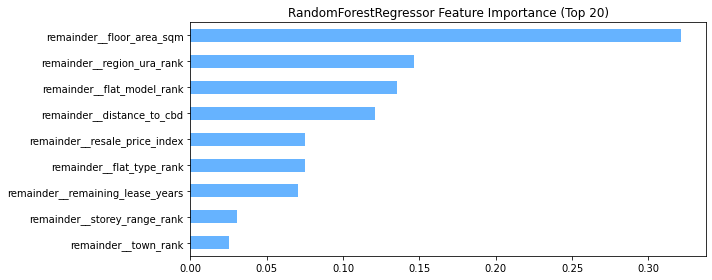

In [ ]:
# Extract feature names and the fitted model step for plotting
feature_names_rf = best_model_pipeline.named_steps['preprocessor'].get_feature_names_out()
rf_model_step = best_model_pipeline.named_steps['rf']

# Plot feature importance (Top 20)
plt.figure(figsize=(10, 4))
feat_imp_rf = pd.Series(rf_model_step.feature_importances_, index=feature_names_rf).sort_values(ascending=False).head(20).sort_values(ascending=True)
feat_imp_rf.plot(kind='barh', color='#66b3ff')
plt.title('RandomForestRegressor Feature Importance (Top 20)')
plt.tight_layout()
plt.show()